# LC Notebook Diff E2E Test - Basic Functionality on Notebook 7

- Test that LC Notebook Diff extension works properly on Notebook 7
- Verify that Diff tab is accessible
- Verify that file selection and diff display work correctly

In [1]:
notebook7_url = "http://localhost:8888/tree?token=test-token"
default_result_path = None
close_on_fail = False
transition_timeout = 10000
default_delay = 200
browser_type = "chromium"
jupyter_work_dir = '../artifacts/jupyter-work'

In [2]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

'/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpxcvun5_c'

In [3]:
import re
import asyncio
import importlib

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *

import scripts.jupyterlab as jupyterlab
importlib.reload(jupyterlab)

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path, delay=default_delay, browser_type=browser_type)

('20251114-181605',
 '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpj_rm6yf1')

## Open Notebook 7 and wait for it to load

Start epoch: 1763111765.30161 seconds
Notebook 7 loaded successfully


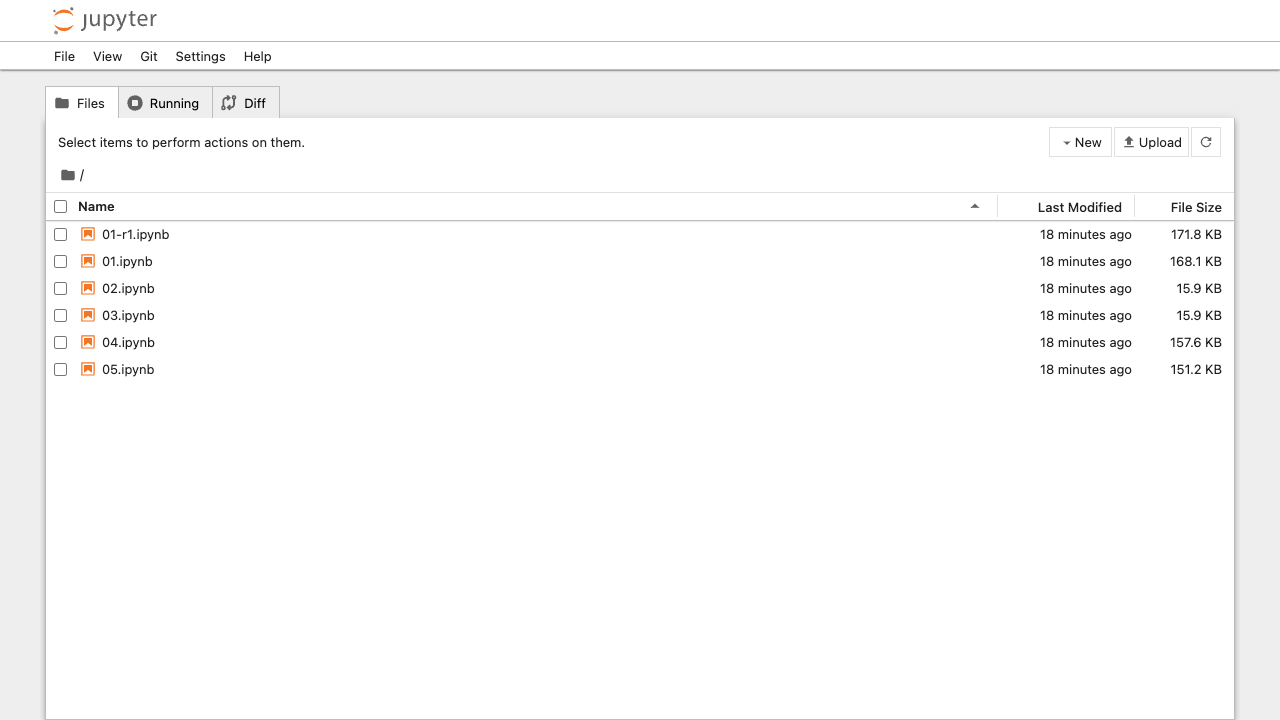

In [4]:
tree_page = None

async def _step(page):
    await page.goto(notebook7_url)

    # Wait for Notebook 7 file browser to load
    await expect(page.locator('.jp-DirListing')).to_be_visible(timeout=transition_timeout)

    global tree_page
    tree_page = page
    
    print("Notebook 7 loaded successfully")

await run_pw(_step)

## Click on Diff tab in main area to open Diff widget

Start epoch: 1763111768.385026 seconds
Clicked on Diff tab in main area
Found 3 file input fields
Show Diff button is visible


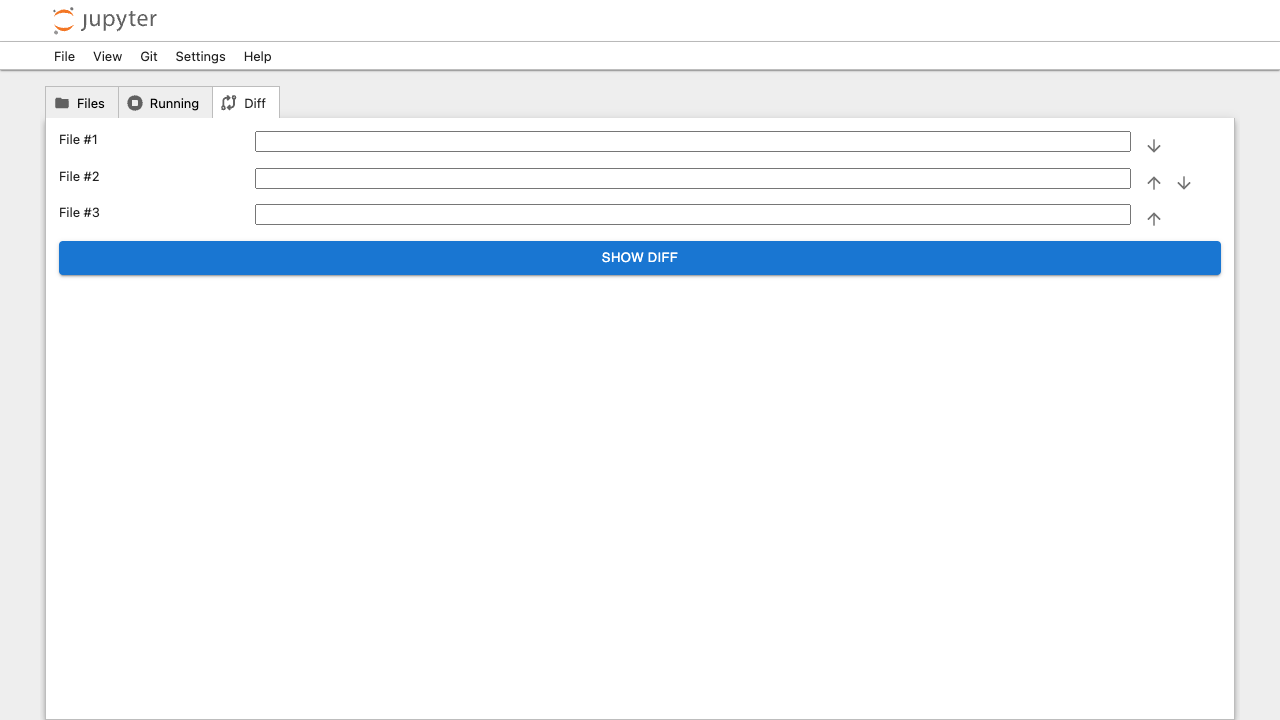

In [5]:
async def _step(page):
    # In Notebook 7, Diff widget is added as a tab in main area
    # Look for tab with "Diff" label
    diff_tab = page.locator('.lm-TabBar-tabLabel:has-text("Diff")')
    await expect(diff_tab).to_be_visible(timeout=transition_timeout)
    await diff_tab.click()
    
    print("Clicked on Diff tab in main area")
    
    # Verify that file input fields are visible
    file_inputs = page.locator('.jupyter-notebook-diff-files input')
    await expect(file_inputs).to_have_count(3, timeout=transition_timeout)
    
    print("Found 3 file input fields")
    
    # Verify that Show Diff button is visible
    show_diff_button = page.locator('button.jupyter-notebook-diff-show-diff')
    await expect(show_diff_button).to_be_visible(timeout=transition_timeout)
    
    print("Show Diff button is visible")

await run_pw(_step)

## Enter notebook paths and click Show Diff

Start epoch: 1763111768.809942 seconds
Entered 01.ipynb in File #1
Entered 01-r1.ipynb in File #2
Clicked Show Diff button


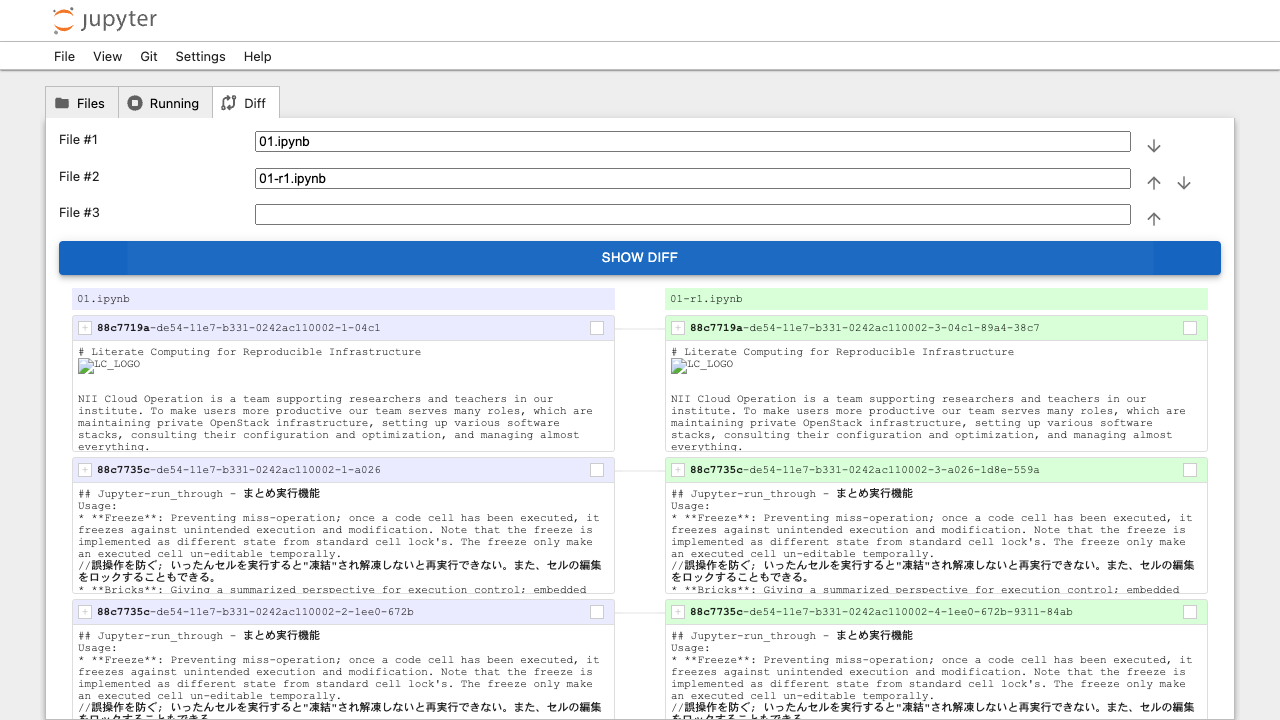

In [6]:
async def _step(page):
    # Enter paths for two notebooks to compare
    file_inputs = page.locator('.jupyter-notebook-diff-files input')
    
    # Fill first input with 01.ipynb
    first_input = file_inputs.nth(0)
    await first_input.fill('01.ipynb')
    print("Entered 01.ipynb in File #1")
    
    # Fill second input with 01-r1.ipynb
    second_input = file_inputs.nth(1)
    await second_input.fill('01-r1.ipynb')
    print("Entered 01-r1.ipynb in File #2")
    
    # Click Show Diff button
    show_diff_button = page.locator('button.jupyter-notebook-diff-show-diff')
    await show_diff_button.click()
    
    print("Clicked Show Diff button")

await run_pw(_step)

## Verify that diff content is displayed

Start epoch: 1763111769.32499 seconds
Diff widget is visible
Diff wrapper is visible
Diff view is displaying 39 cells correctly


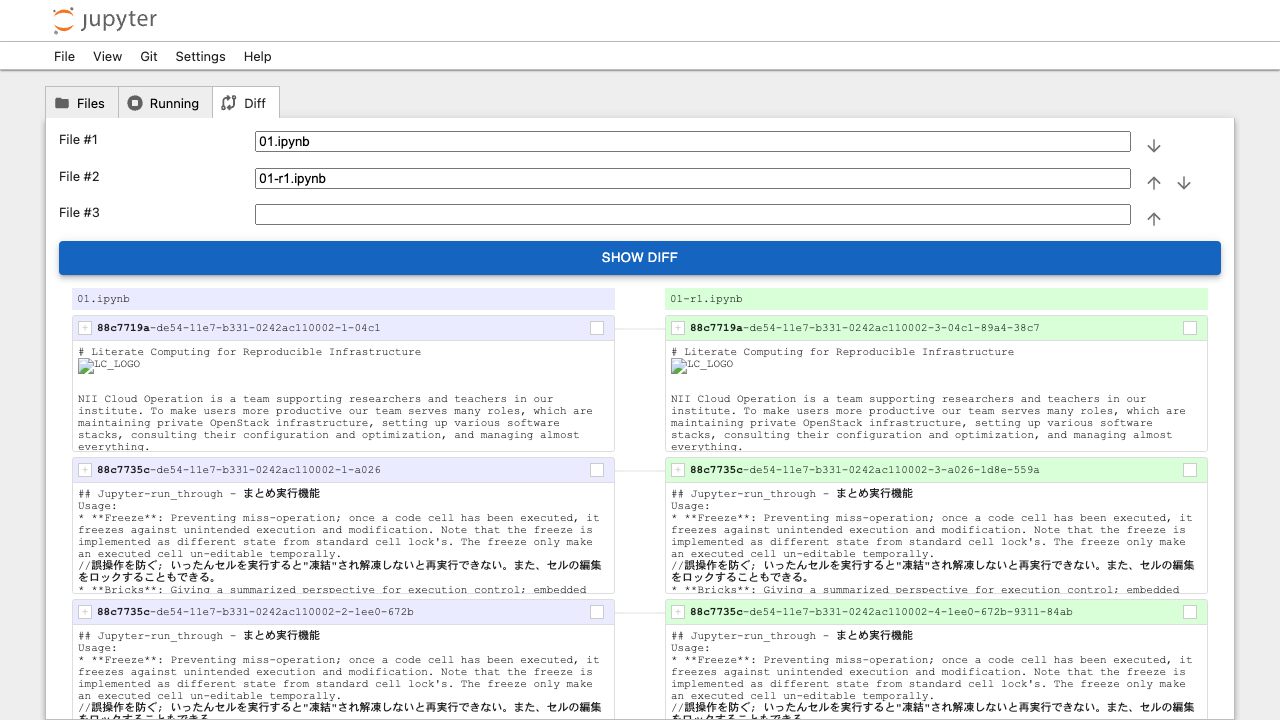

In [7]:
async def _step(page):
    # Verify that diff widget is visible
    diff_widget = page.locator('.jupyter-notebook-diff')
    await expect(diff_widget).to_be_visible(timeout=transition_timeout)
    
    print("Diff widget is visible")
    
    # Verify that wrapper element exists (from DiffView.ts:308)
    wrapper = page.locator('.jupyter-notebook-diff .wrapper')
    await expect(wrapper).to_be_visible(timeout=transition_timeout)
    
    print("Diff wrapper is visible")
    
    # Verify that cell elements are rendered
    # 01.ipynb has 19 cells, 01-r1.ipynb has 20 cells, so total 39 cells
    cells = page.locator('.jupyter-notebook-diff .cell')
    await expect(cells).to_have_count(39, timeout=transition_timeout)
    
    print("Diff view is displaying 39 cells correctly")

await run_pw(_step)

## Clean up

In [8]:
await finish_pw_context()

Video: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpxcvun5_c/video-1.webm
HAR: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpxcvun5_c/har.zip
Console log: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpxcvun5_c/console.log


スクリーンキャプチャ動画の取得に失敗しました。
Traceback (most recent call last):
  File "/Users/yazawa/workspace/nii-cloud/Jupyter-LC_notebook_diff/ui-tests/e2e-notebook/notebooks/scripts/playwright.py", line 254, in _finish_pw_context
    shutil.copyfile(video_path, dest_video_path)
  File "/Users/yazawa/.pyenv/versions/3.11.5/lib/python3.11/shutil.py", line 256, in copyfile
    with open(src, 'rb') as fsrc:
         ^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpj_rm6yf1/videos/9c5a9226411a7a73e511fb72de5a309c.webm'


In [9]:
!rm -fr {work_dir}